<a href="https://colab.research.google.com/github/sofol-bit/LinSofoNEUR265/blob/main/final/FinalEDU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import modules

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skewtest
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr

In [4]:
#import data

EDU = pd.read_csv('https://raw.githubusercontent.com/sofol-bit/LinSofoNEUR265/refs/heads/main/final/EDU%20-%20AT8%20-%20Iba1.csv')

In [5]:
#check data

print(EDU)

    EDU   AT8  Iba1
0    17  1222  8152
1    16     2  5733
2    12  1561  8824
3    15   118  1119
4    12   100   448
..  ...   ...   ...
79   16   706  5182
80   15   839  5887
81   12   175  6505
82   17  1723  5874
83   21     6  3622

[84 rows x 3 columns]


In [6]:
#split data into low and high edu groups

EDU["EDU_group"] = EDU["EDU"].apply(lambda x: "<=12" if x <= 12 else ">12")

low_edu = EDU[EDU["EDU_group"] == "<=12"]
high_edu = EDU[EDU["EDU_group"] == ">12"]

AT8 skew test: SkewtestResult(statistic=np.float64(4.966547926273179), pvalue=np.float64(6.815521551418227e-07))
Iba1 skew test: SkewtestResult(statistic=np.float64(4.068250488493177), pvalue=np.float64(4.7367446120348714e-05))


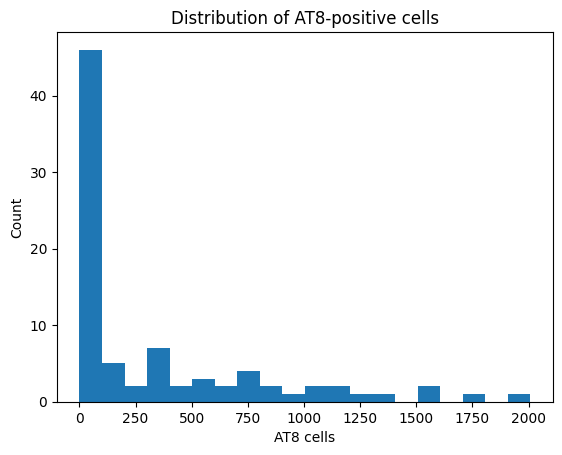

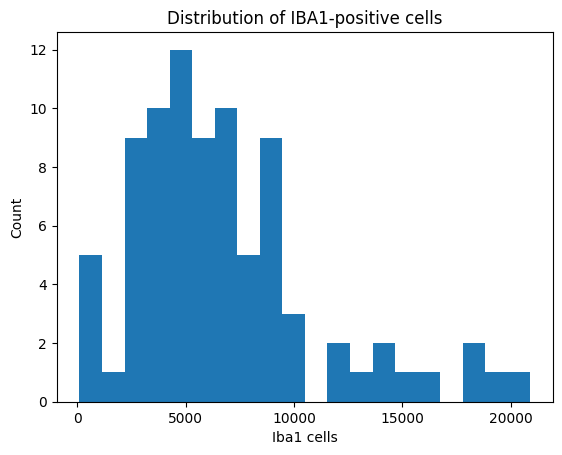

In [7]:
#skew and plot dist of dependent variables
print("AT8 skew test:", skewtest(EDU["AT8"]))
print("Iba1 skew test:", skewtest(EDU["Iba1"]))

#AT8
plt.figure()
plt.hist(EDU["AT8"], bins=20)
plt.title("Distribution of AT8-positive cells")
plt.xlabel("AT8 cells")
plt.ylabel("Count")
plt.show()

#Iba1
plt.figure()
plt.hist(EDU["Iba1"], bins=20)
plt.title("Distribution of IBA1-positive cells")
plt.xlabel("Iba1 cells")
plt.ylabel("Count")
plt.show()

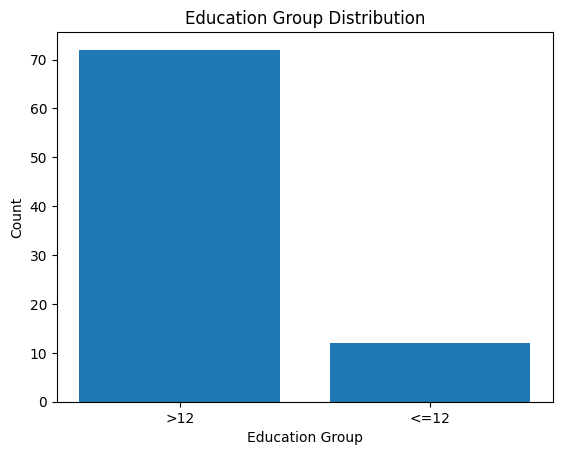

In [8]:
#plot dist of grouping variable(years of edu)

counts = EDU["EDU_group"].value_counts()

plt.figure()
plt.bar(counts.index, counts.values)
plt.title("Education Group Distribution")
plt.xlabel("Education Group")
plt.ylabel("Count")
plt.show()

Spearman (<=12): -0.06293706293706294 p = 0.8459309212287789
Spearman (>12): 0.10440979973857518 p = 0.3827556766888157


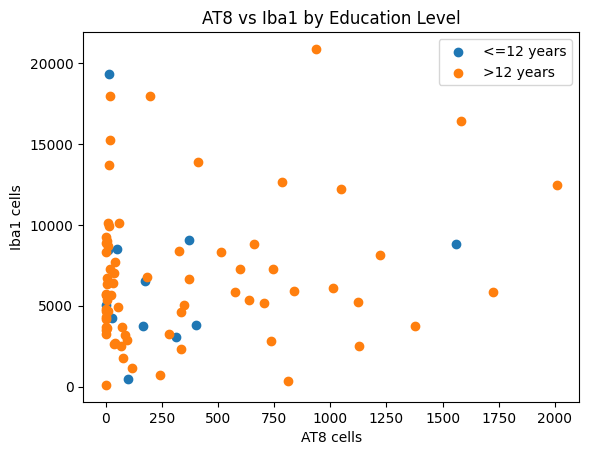

In [9]:
#corr coefficient scatterplot of relationship between each DV, color coded
rho_low, p_low = spearmanr(low_edu["AT8"], low_edu["Iba1"])
rho_high, p_high = spearmanr(high_edu["AT8"], high_edu["Iba1"])

print("Spearman (<=12):", rho_low, "p =", p_low)
print("Spearman (>12):", rho_high, "p =", p_high)

plt.figure()
plt.scatter(low_edu["AT8"], low_edu["Iba1"], label="<=12 years")
plt.scatter(high_edu["AT8"], high_edu["Iba1"], label=">12 years")

plt.title("AT8 vs Iba1 by Education Level")
plt.xlabel("AT8 cells")
plt.ylabel("Iba1 cells")
plt.legend()
plt.show()

AT8 Mann-Whitney p-value: 0.8830860733636765
IBA1 Mann-Whitney p-value: 0.9541290836092371


/tmp/ipykernel_54607/3677413523.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([low_edu["AT8"], high_edu["AT8"]], labels=["<=12", ">12"])


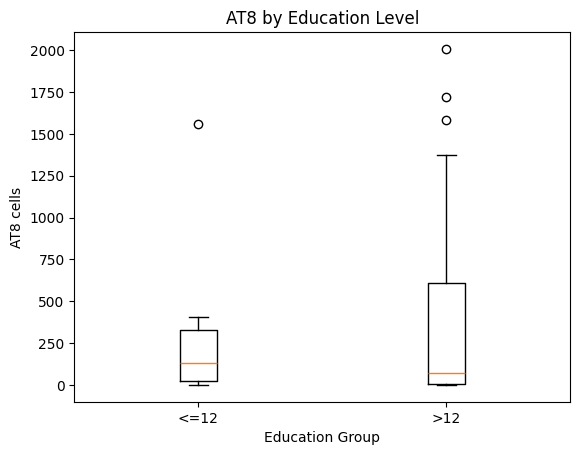

/tmp/ipykernel_54607/3677413523.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([low_edu["Iba1"], high_edu["Iba1"]], labels=["<=12", ">12"])


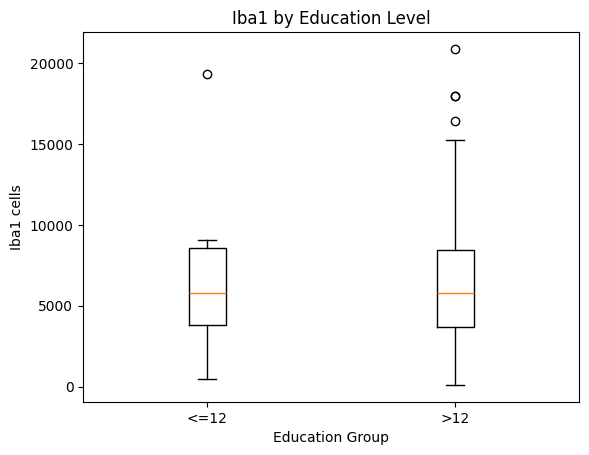

In [10]:
#stat tests, boxplots, how each DV varies by grouping variable
# Mann-Whitney U-Tests
u_at8, p_at8 = mannwhitneyu(low_edu["AT8"], high_edu["AT8"], alternative='two-sided')
print("AT8 Mann-Whitney p-value:", p_at8)
u_iba1, p_iba1 = mannwhitneyu(low_edu["Iba1"], high_edu["Iba1"], alternative='two-sided')
print("IBA1 Mann-Whitney p-value:", p_iba1)

# AT8
plt.figure()
plt.boxplot([low_edu["AT8"], high_edu["AT8"]], labels=["<=12", ">12"])
plt.title("AT8 by Education Level")
plt.xlabel("Education Group")
plt.ylabel("AT8 cells")
plt.show()

# IBA1
plt.figure()
plt.boxplot([low_edu["Iba1"], high_edu["Iba1"]], labels=["<=12", ">12"])
plt.title("Iba1 by Education Level")
plt.xlabel("Education Group")
plt.ylabel("Iba1 cells")
plt.show()